In [63]:

import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [64]:
fb1 = pd.read_csv('race_wins_1950-2020.csv', header=0, index_col=0, parse_dates=True)

/tmp/ipykernel_1486/2425830707.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fb1 = pd.read_csv('race_wins_1950-2020.csv', header=0, index_col=0, parse_dates=True)


In [65]:
fb1.head()

,Venue,Date,Name,NameTag,Team,Laps,Time
0,Great Britain,13.05.1950,Nino Farina,FAR,Alfa Romeo,70.0,2:13:23.600
1,Monaco,21.05.1950,Juan Manuel Fangio,FAN,Alfa Romeo,100.0,3:13:18.700
2,Indianapolis 500,30.05.1950,Johnnie Parsons,PAR,Kurtis Kraft Offenhauser,138.0,2:46:55.970
3,Switzerland,04.06.1950,Nino Farina,FAR,Alfa Romeo,42.0,2:02:53.700
4,Belgium,18.06.1950,Juan Manuel Fangio,FAN,Alfa Romeo,35.0,2:47:26.000


In [66]:
ts_fb = pd.read_csv('race_wins_1950-2020.csv', header=0, index_col=0, parse_dates=True)
ts_ms = pd.read_csv('race_wins_1950-2020.csv', header=0, index_col=0, parse_dates=True)

/tmp/ipykernel_1486/1945217356.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts_fb = pd.read_csv('race_wins_1950-2020.csv', header=0, index_col=0, parse_dates=True)
/tmp/ipykernel_1486/1945217356.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts_ms = pd.read_csv('race_wins_1950-2020.csv', header=0, index_col=0, parse_dates=True)


In [67]:
ts_fb.head()

,Venue,Date,Name,NameTag,Team,Laps,Time
0,Great Britain,13.05.1950,Nino Farina,FAR,Alfa Romeo,70.0,2:13:23.600
1,Monaco,21.05.1950,Juan Manuel Fangio,FAN,Alfa Romeo,100.0,3:13:18.700
2,Indianapolis 500,30.05.1950,Johnnie Parsons,PAR,Kurtis Kraft Offenhauser,138.0,2:46:55.970
3,Switzerland,04.06.1950,Nino Farina,FAR,Alfa Romeo,42.0,2:02:53.700
4,Belgium,18.06.1950,Juan Manuel Fangio,FAN,Alfa Romeo,35.0,2:47:26.000


In [68]:
ts_fb.shape

(1038, 7)

In [69]:
ts_fb['Date']

,Date
0,13.05.1950
1,21.05.1950
2,30.05.1950
3,04.06.1950
4,18.06.1950
...,...
1033,01.11.2020
1034,15.11.2020
1035,29.11.2020
1036,06.12.2020


In [70]:
fb1['Laps'] = fb1['Laps'].fillna(0)

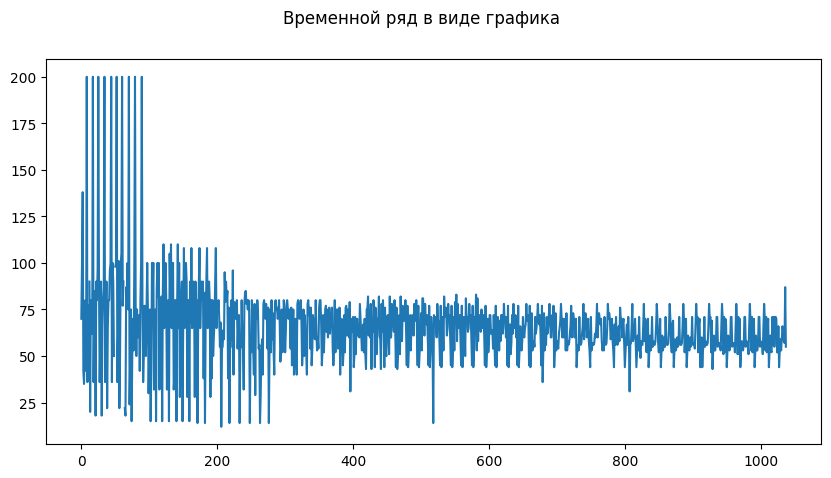

In [71]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд в виде графика')
ts_fb.plot(ax=ax, legend=False)
pyplot.show()

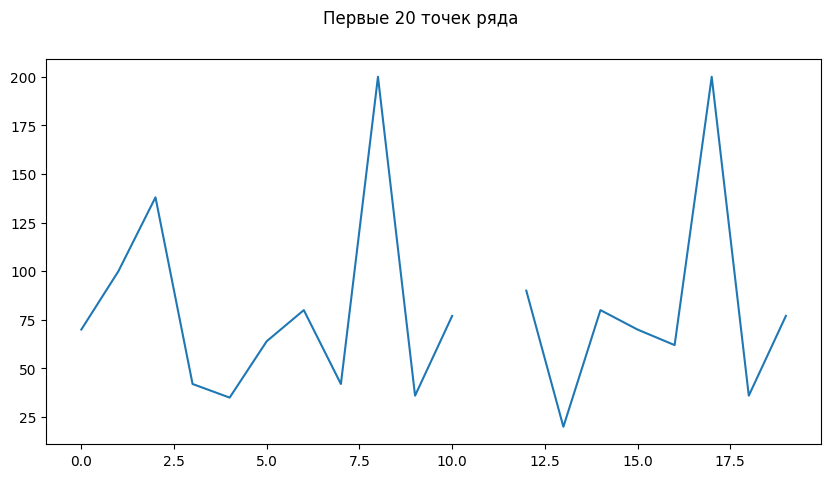

In [72]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Первые 20 точек ряда')
ts_fb[:20].plot(ax=ax, legend=False)
pyplot.show()

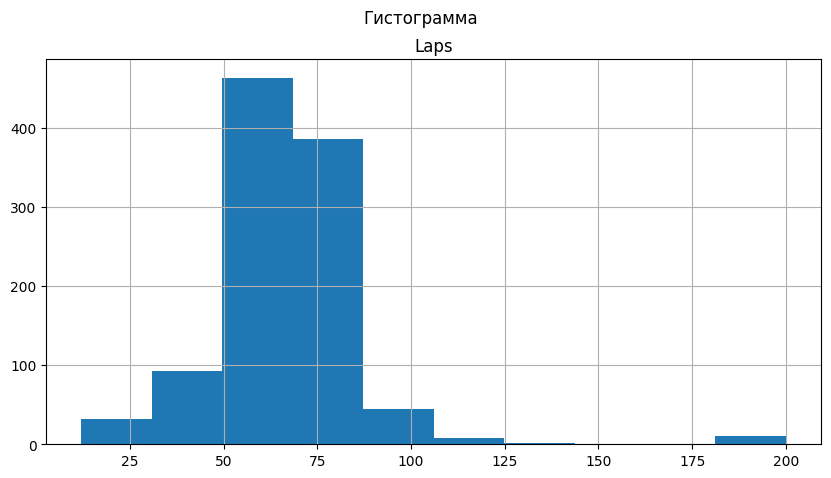

In [73]:

fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Гистограмма')
ts_fb.hist(ax=ax, legend=False)
pyplot.show()

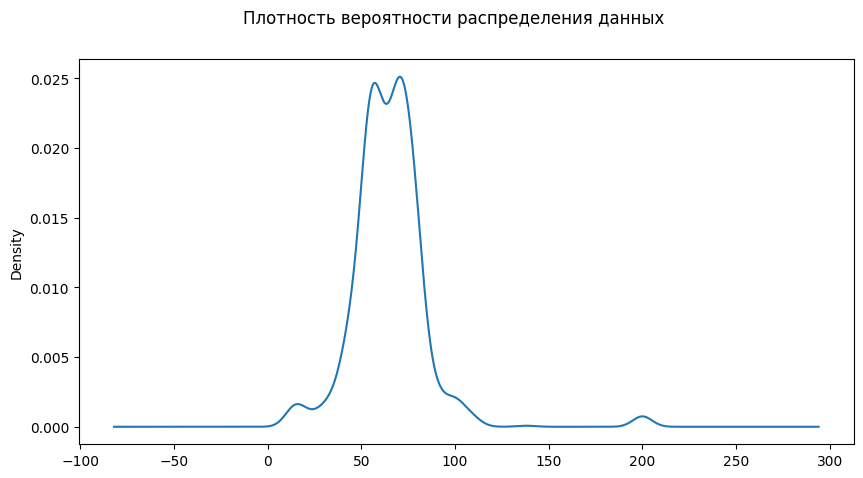

In [74]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Плотность вероятности распределения данных')
ts_fb.plot(ax=ax, kind='kde', legend=False)
pyplot.show()

TypeError: unhashable type: 'numpy.ndarray'

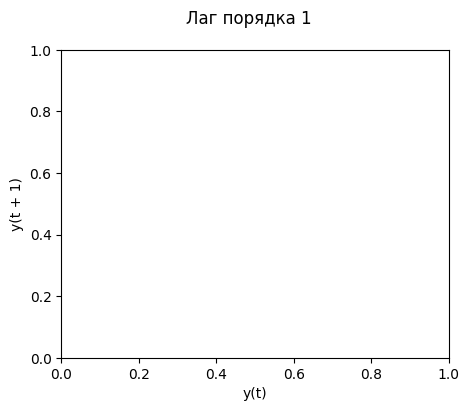

In [75]:
for i in range(1, 5):
    fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(5,4))
    fig.suptitle(f'Лаг порядка {i}')
    pd.plotting.lag_plot(ts_fb, lag=i, ax=ax)
    pyplot.show()

In [ ]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Автокорреляционная диаграмма')
pd.plotting.autocorrelation_plot(ts_fb, ax=ax)
pyplot.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(ts_fb, lags=30)
plt.tight_layout()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Аддитивная модель
def plot_decompose(data=ts_fb['Date'], model='add'):
    result_add = seasonal_decompose(data, model = 'add')
    fig = result_add.plot()
    fig.set_size_inches((10, 8))
    # Перерисовка
    fig.tight_layout()
    plt.show()

In [76]:
plot_decompose(data=ts_fb['Laps'], model='add')

ValueError: This function does not handle missing values

In [77]:
plot_decompose(data=ts_fb['Laps'], model='mul')

ValueError: This function does not handle missing values

In [79]:
plot_decompose(data=ts_ms['Laps'], model='add')

ValueError: This function does not handle missing values

In [80]:
ts_fb2 = ts_fb.copy()

In [81]:
ts_fb2['SMA_10'] = ts_fb2['Laps'].rolling(10, min_periods=1).mean()
ts_fb2['SMA_20'] = ts_fb2['Laps'].rolling(20, min_periods=1).mean()

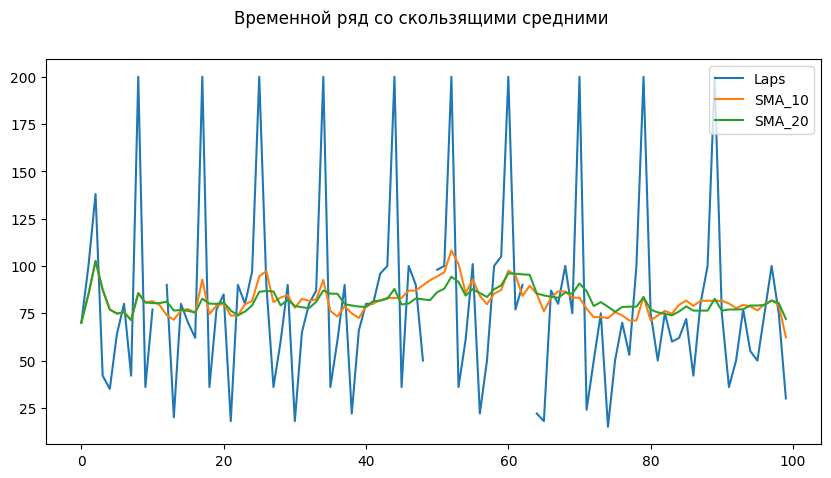

In [82]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд со скользящими средними')
ts_fb2[:100].plot(ax=ax, legend=True)
pyplot.show()

In [83]:
xnum = list(range(ts_fb2.shape[0]))
# Разделение выборки на обучающую и тестовую
Y = ts_fb2['Laps'].values
train_size = int(len(Y) * 0.7)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]
history_arima = [x for x in train]
history_es = [x for x in train]

In [84]:
arima_order = (6,1,0)
# Формирование предсказаний
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])
# Вычисление метрики RMSE
error_arima = mean_squared_error(test, predictions_arima, squared=False)

TypeError: got an unexpected keyword argument 'squared'

In [85]:
predictions_es = list()
for t in range(len(test)):
    model_es = ExponentialSmoothing(history_es)
    model_es_fit = model_es.fit()
    yhat_es = model_es_fit.forecast()[0]
    predictions_es.append(yhat_es)
    history_es.append(test[t])
# Вычисление метрики RMSE
error_es = mean_squared_error(test, predictions_es, squared=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_

TypeError: got an unexpected keyword argument 'squared'

In [86]:
np.mean(Y), error_arima, error_es

NameError: name 'error_arima' is not defined

In [87]:
ts_fb2['predictions_ARIMA'] = (train_size * [np.NAN]) + list(predictions_arima)
ts_fb2['predictions_HWES'] = (train_size * [np.NAN]) + list(predictions_es)

AttributeError: module 'numpy' has no attribute 'NAN'

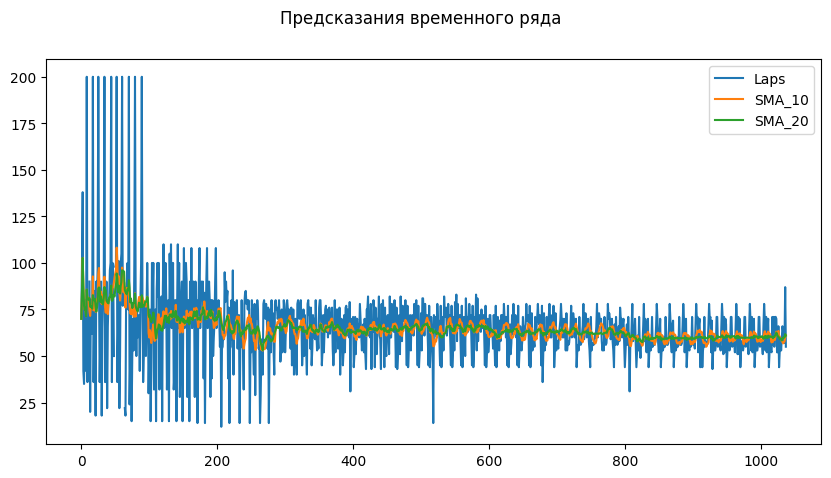

In [92]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда')
ts_fb2.plot(ax=ax, legend=True)
pyplot.show()

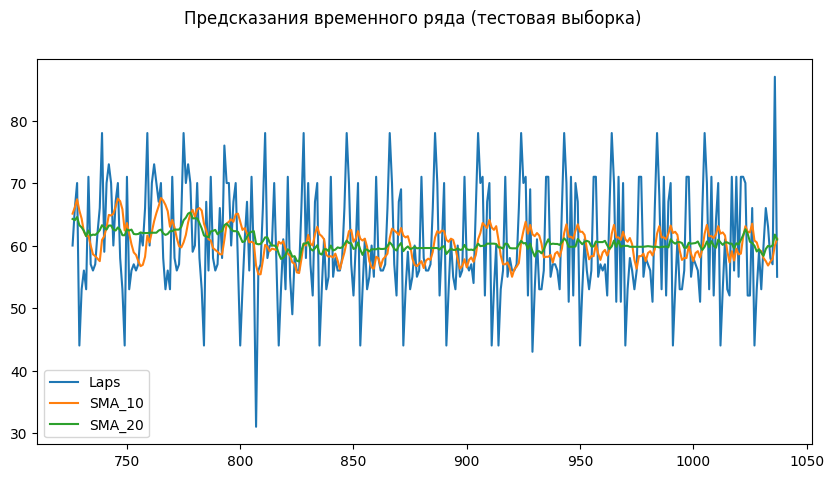

In [91]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
ts_fb2[train_size:].plot(ax=ax, legend=True)
pyplot.show()

In [ ]:
import graphviz
dot_data = est_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
graph

In [ ]:
y_gp = est_gp.predict(np.array(xnum_test).reshape(-1, 1))
y_gp[:10]

In [90]:
ts_fb2['Laps'] = (train_size * [np.NAN]) + list(y_gp)

AttributeError: module 'numpy' has no attribute 'NAN'

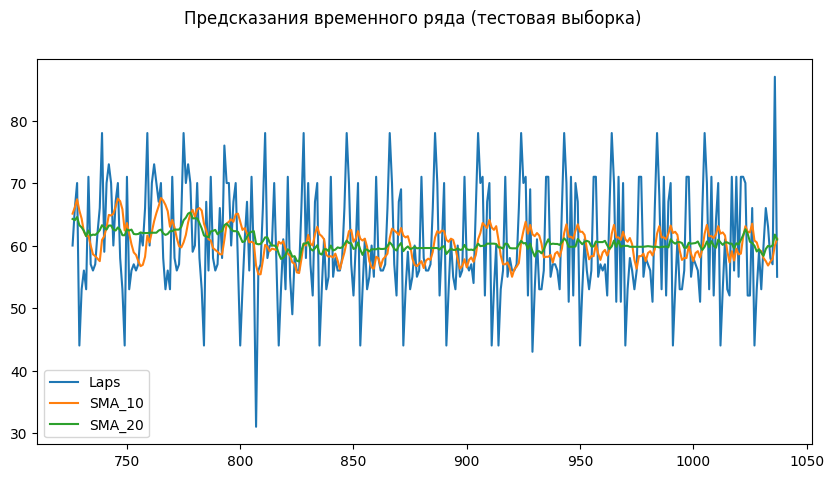

In [88]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
ts_fb2[train_size:].plot(ax=ax, legend=True)
pyplot.show()